# 4. Two-island model

Formålet med denne notebook er at bygge en two-island model og bruge den til inferens. Modellen beskriver to populationer, hvor linjer kan migrere mellem øerne, men der er ingen fælles forfader-population (migration alene opretholder forbindelsen), der er en konstant rate. Dette er den simpleste model som jeg laver først, før jeg går videre til isolation with migration (IM) modellen i notebook 05.

I artiklen af Sørensen et al. 2023 dokumenteres admixture mellem eastern yellow baboons og Kinda baboons. De er tæt forbundet og der er geneflow mellem dem. Two island modellen kan give en konstant migrationsestimat. 

Jeg kommer i denne notebook ind på følgende:

1. Byg two-island model
2. Teoretiske egenskaber
3. Joint-probability graf og SFS inference med SVGD
4. Simuler testdata med msprime
5. Validering: genfind sande parametre fra msprime-simulering
6. Anvende modellen på bavian-data (Yellow baboon vs. Kinda baboon) fra notebook 03
7. Samlet resultater

Indlæs data fra notebook 03

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

# phasic importeres først for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
import msprime

from vscodenb import set_vscode_theme
all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
sns.set_palette("tab10")


MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)


print("Imports OK")

Imports OK


## Definer staterummet

Jeg bruger *StateIndexer* og *Property* til at definere en struktureret statevektor:

- $pop1$: antal efterkommere fra population 1
- $pop2$: antal efterkommere fra population 2  
- $in_{pop}$: hvilken population linjen befinder sig i (1 eller 2)

In [2]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

# Initial state: alle linjer fra pop1, befinder sig i pop1
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

print(f"State vector length: {indexer.state_length}")
print(f"Initial state: {initial}")

State vector length: 18
Initial state: [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


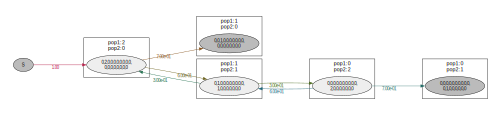

In [3]:
@with_ipv(initial)
def two_island(state):
    transitions = []

    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, 
                    pop2=des_pop2, 
                    in_pop=props_i.in_pop
                    )
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, 
                pop2=props_i.pop2, 
                in_pop=other_pop
                )
            child[k] += 1

            transitions.append([child, [0, state[i]]])

    return transitions

graph = Graph(two_island)   

true_theta = [0.7, 0.3]
graph.update_weights(true_theta)

def label(state):
    nr_pop1 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 1) for i in indexer])
    nr_pop2 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 2) for i in indexer])
    return f"pop1: {nr_pop1}\npop2: {nr_pop2}"

graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, 
                    #   label_fmt=False, 
                      by_state=label)

## Effekt af migration på coalescent-processen

Undersøger hvordan migrationsraten påvirker:

1. Den forventede TMRCA
2. Fordelingen (PDF) af TMRCA

Høj migration $\rightarrow$ populationerne opfører sig næsten som en stor population $\rightarrow$ kortere coalescent-tider og mere jævn SFS. 
Lav migration $\rightarrow$ populationerne er mere isolerede $\rightarrow$ længere og mere varierende coalescent-tider.

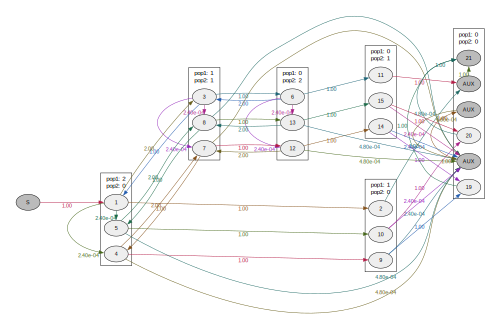

In [4]:
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_only=['pop1', 'pop2'],
                                          reward_limit=1,
                                          tot_reward_limit=1, 
                                          mutation_rate=mutation_rate)

joint_prob_graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, label_fmt=False, by_state=label)

In [5]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
18,0,0,0,0,0,0,0.999041
19,0,1,0,0,0,0,0.000479
20,0,0,0,1,0,0,0.000479


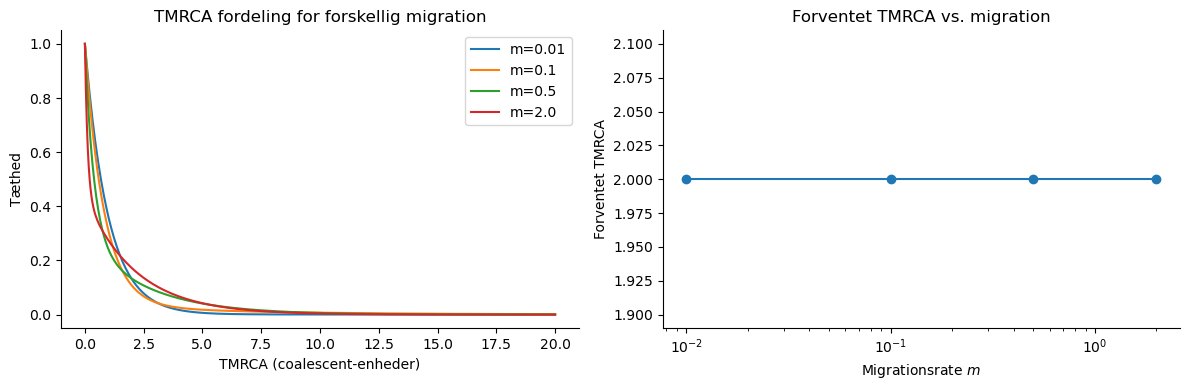

m=0.01: E[TMRCA] = 2.000
m=0.10: E[TMRCA] = 2.000
m=0.50: E[TMRCA] = 2.000
m=2.00: E[TMRCA] = 2.000


In [8]:
# Undersøg effekt af migration
N = 1  # N_e i coalescent-enheder (normaliseret)
migration_rates = [0.01, 0.1, 0.5, 2.0]
t_range = np.linspace(0, 20, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

expectations = []
for m in migration_rates:
    graph.update_weights([1/N, m])
    pdfs = graph.pdf(t_range)
    e_tmrca = graph.expectation()
    expectations.append(e_tmrca)
    axes[0].plot(t_range, pdfs, label=f'm={m}')

axes[0].set_xlabel('TMRCA (coalescent-enheder)')
axes[0].set_ylabel('Tæthed')
axes[0].set_title('TMRCA fordeling for forskellig migration')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].plot(migration_rates, expectations, 'o-', color='C0')
axes[1].set_xlabel('Migrationsrate $m$')
axes[1].set_ylabel('Forventet TMRCA')
axes[1].set_title('Forventet TMRCA vs. migration')
axes[1].set_xscale('log')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

for m, e in zip(migration_rates, expectations):
    print(f"m={m:.2f}: E[TMRCA] = {e:.3f}")

## SVGD-inferens: Estimer N og m

Nu estimerer jeg begge parametre simultant: coalescent-rate ($\theta_c = 1/N$) og migrationsrate ($\theta_m = m$).

Jeg genererer testdata fra kendte parametre og ser om SVGD kan genfinde dem.

In [9]:
# Sæt sande parametre og generer data
true_theta = [0.7, 0.9]  # [coalescent-rate, migrationsrate]
graph.update_weights(true_theta)

nr_observations = 1000
observed_data = graph.sample(nr_observations)

print(f"Sand theta = {true_theta}")
print(f"Svarende til N = {1/true_theta[0]:.1f}, m = {true_theta[1]:.2f}")
print(f"Forventet TMRCA: {graph.expectation():.3f}")
print(f"Median observeret TMRCA: {np.median(observed_data):.3f}")

Sand theta = [0.7, 0.9]
Svarende til N = 1.4, m = 0.90
Forventet TMRCA: 2.857
Median observeret TMRCA: 1.758


In [10]:
# Kør SVGD med to parametre
svgd = graph.svgd(
    observed_data,
    prior=[
        HalfCauchyPrior(ci=2.0, prob=0.9),   # Prior for coalescent-rate
        HalfCauchyPrior(ci=1.0, prob=0.9),   # Prior for migrationsrate
    ],
    optimizer=Adam(learning_rate=0.05),
    n_iterations=300,
    n_particles=40,
)
svgd.summary()

W0501 10:29:13.309198  121945 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.7081     0.5736     0.1706     0.3530       0.7129      
1          No         0.7779     0.4876     0.3777     0.0002       0.7969      

Particles: 40, Iterations: 300


In [11]:
# Sæt sande parametre og simuler data
true_theta = [0.7, 0.9] # coalescence-rate, migrationrate
graph.update_weights(true_theta)
observations = graph.sample(1000)

print(f"Two-island model: {graph.param_length()} parametre")
print(f"theta[0] = coalescence-rate = {true_theta[0]} (1/N_e)")
print(f"theta[1] = migrationrate = {true_theta[1]}")

# MoM estimering som udgangspunkt
mom= graph.method_of_moments(observations)

print(" MoM estimat (two-island model)")
print(f"Sand theta: {true_theta}")
print(f"MoM estimat: {mom.theta}")
print(f"Std. fejl: {mom.std}")
print(f"Konvergeret: {mom.success}")

Two-island model: 2 parametre
theta[0] = coalescence-rate = 0.7 (1/N_e)
theta[1] = migrationrate = 0.9


W0501 10:29:19.864538  121945 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0501 10:29:19.982041  121945 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0501 10:29:19.993042  121945 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


 MoM estimat (two-island model)
Sand theta: [0.7, 0.9]
MoM estimat: [0.71486244 1.47162627]
Std. fejl: [0.02395124 0.8136703 ]
Konvergeret: True


W0501 10:29:23.195028  121945 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


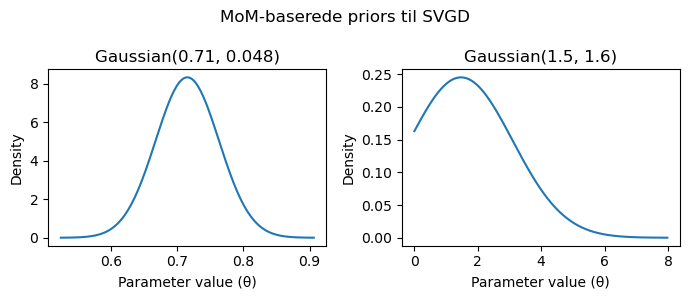

In [12]:
# SVGD med prior fra MoM-resultatet
# MoM giver automatisk et fornuftigt informeret prior
fig, axes = plt.subplots(1, len(mom.prior), figsize=(7, 3))
for i, prior in enumerate(mom.prior):
    prior.plot(return_ax=True, ax=axes[i])
plt.suptitle("MoM-baserede priors til SVGD")
plt.tight_layout()
plt.show()

In [13]:
# Kør SVGD inferens på two-island modellen med mom.prior
svgd = graph.svgd(
    observations,
    prior=mom.prior,
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
    n_devices=1,
)

print("SVGD Resultat (two-island model)")
svgd.summary()

SVGD Resultat (two-island model)
Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.7136     0.2848     0.3609     0.0000       1.2184      
1          No         1.6595     0.2516     0.5961     0.0000       1.6595      

Particles: 40, Iterations: 100


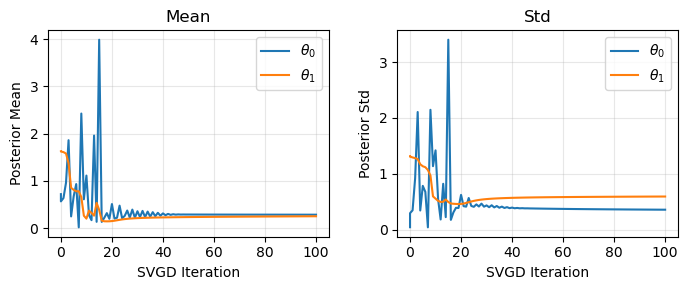

In [14]:
svgd.plot_convergence()

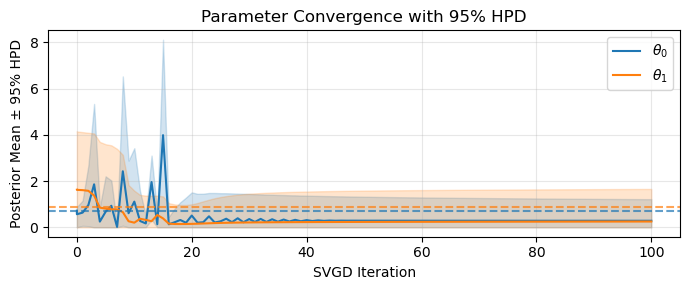

In [15]:
svgd.plot_ci(true_theta=true_theta)

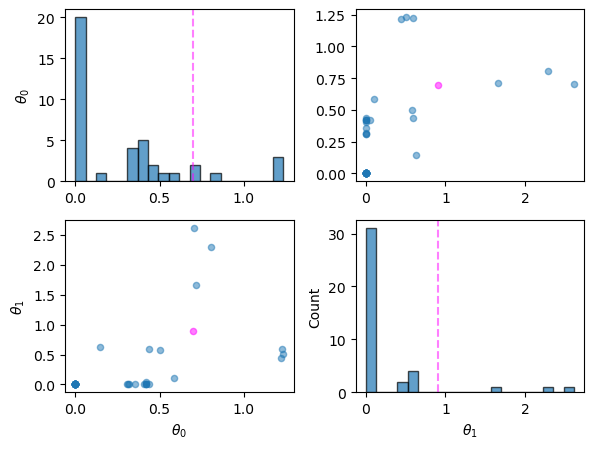

In [16]:
# Vis joint posterior (2D)
svgd.plot_pairwise(true_theta=true_theta)

## Alternativ konstruktion af two-island modellen

Jeg omskriver modellen med en lidt anderledes state-design, der er mere fleksibel til the efterfølgende analyser. I stedet for den samlede state-vektor fra den første model, adskiller jeg nu eksplicit:

- **descendants**: Antal samples en lineage bærer — bruges til SFS-beregning via rewards
- **in_pop**: Hvilken population lineagen befinder sig i (1 eller 2)

Med *nr_samples* $= 4$ samples trukket fra population 1 kan modellen nu have 3 separate parametre:

| Index | Parameter | Beskrivelse |
|------:|-----------|-------------|
| 0 | $1/N_1$ | Coalescence-rate i population 1 |
| 1 | $1/N_2$ | Coalescence-rate i population 2 |
| 2 | $m$ | Symmetrisk migrationsrate |

At adskille $N_1$ og $N_2$ er relevant to bavian-populationer har typisk forskellige effektive populationsstørrelser. Den ekstra parameter giver en bedre model men kræver mere data for stabil estimering.

Antal vertices i to-island grafen: 21
Antal parametre: 3
Two-island model: 21 state, 3 parametre


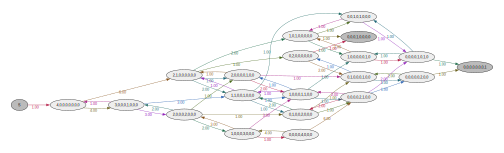

In [17]:
nr_samples = 4

indexer = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)

# Startstate: alle lineages er singletons i population 1
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv)
def two_island(state, indexer=None):
    transitions = []
    if state.sum() <= 1:
        return transitions

    # Coalescence inden for hver population
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop:
            continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = [rate if pi.in_pop == 1 else 0,
                 rate if pi.in_pop == 2 else 0,
                 0]
        transitions.append([new, coeff])

    # Migration (symmetrisk rate m)
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy()
        new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        coeff = [0, 0, state[i]]  # migration-koefficient
        transitions.append([new, coeff])

    return transitions

graph_2i = Graph(two_island, indexer=indexer)
print(f"Antal vertices i to-island grafen: {graph_2i.vertices_length()}")
print(f"Antal parametre: {graph_2i.param_length()}")
print(f"Two-island model: {graph_2i.vertices_length()} state, {graph_2i.param_length()} parametre")

graph_2i.plot(nodesep=0.4, wrap=False)

## Teoretiske egenskaber

Med sande parametre $(N_1, N_2, m)=(1,2,0.5)$ beregner jeg forventet TMRCA og SFS under modellen.

In [18]:
# Sande parametre (i coalescent-enheder)
N1_true, N2_true, m_true = 1.0, 2.0, 0.5
true_theta = [1/N1_true, 1/N2_true, m_true]
graph_2i.update_weights(true_theta)

print(f"Forventet TMRCA: {graph_2i.expectation():.4f}")
print(f"Varians på TMRCA: {graph_2i.variance():.4f}")

Forventet TMRCA: 3.8231
Varians på TMRCA: 12.5314


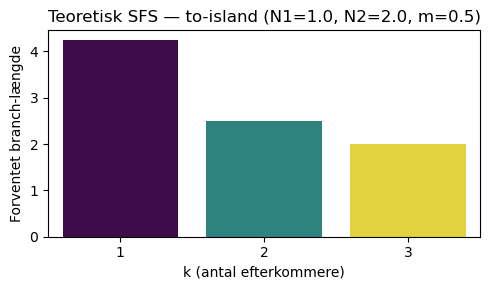

In [19]:
# Beregn forventet SFS ved reward-transform
# Rewarden tæller tid tilbragt med en lineage der har præcis i efterkommere
state_mat = graph_2i.states()
descendants_rewards = []
for k_val in range(1, nr_samples):
    r = np.zeros(state_mat.shape[0])
    for row_idx in range(state_mat.shape[0]):
        for col_idx in range(indexer.state_length):
            props = indexer.lineages.index_to_props(col_idx)
            if props.descendants == k_val:
                r[row_idx] += state_mat[row_idx, col_idx]
    descendants_rewards.append(r)

sfs = np.array([graph_2i.expectation(rewards=r) for r in descendants_rewards])
x = np.arange(1, nr_samples)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("k (antal efterkommere)")
ax.set_ylabel("Forventet branch-længde")
ax.set_title(f"Teoretisk SFS — to-island (N1={N1_true}, N2={N2_true}, m={m_true})")
plt.tight_layout()
plt.show()

## Joint probability graf — diskrete mutations-observationer

For at kunne fitte modellen til rigtige SNP-data laver jeg en joint probability graf, der kobler coalescent-modellen til en Poisson-mutations-proces.

Hver observation er et tupel $(k_1,k_2,...,k_{n-1})$ som fortæller hvor mange singletons, doubletons osv. en lokus-konfiguration har. Mutationsraten indgår som en ekstra parameter.

In [20]:
mutation_rate = 1.0   # i coalescent-enheder — svarer til theta = 4*N*mu*L
joint_graph = graph_2i.joint_prob_graph(
    indexer,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=1000,
    mutation_rate=mutation_rate,
)

true_theta_joint = [1/N1_true, 1/N2_true, m_true, mutation_rate]
joint_graph.update_weights(true_theta_joint)

tbl = joint_graph.joint_prob_table()
print(f"Antal unikke observation-mønstre: {len(tbl)}")
print(f"Deficit (afkortnings-bias): {(1 - tbl['prob'].sum()).item():.4f}")
tbl.head(10)

Antal unikke observation-mønstre: 8
Deficit (afkortnings-bias): 0.8174


,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
97,0,0,0,0,0.058421
98,0,1,0,0,0.020558
99,1,0,0,0,0.050526
100,0,0,1,0,0.012195
101,1,0,1,0,0.016778
102,1,1,0,0,0.018763
103,0,1,1,0,0.001932
104,1,1,1,0,0.003472


## Simuler testdata med msprime
Før jeg bruger bavian-data, laver jeg simuleret data med kendte parametre. Dette er den bedste måde at verificere, at min inferens er troværdig.

In [21]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography_sym = msprime.Demography()
demography_sym.add_population(name="pop1", initial_size=pop1_size)
demography_sym.add_population(name="pop2", initial_size=pop2_size)
# Symmetrisk migration — samme rate begge veje
sym_rate = (migr_pop1_to_pop2 + migr_pop2_to_pop1) / 2
demography_sym.set_migration_rate(source="pop1", dest="pop2", rate=sym_rate)
demography_sym.set_migration_rate(source="pop2", dest="pop1", rate=sym_rate)

ts_sym = msprime.sim_ancestry(
    samples={"pop1": nr_samples, "pop2": 0},
    ploidy=1,
    demography=demography_sym,
    recombination_rate=rec_rate,
    sequence_length=seq_length,
    random_seed=42
)
ts_sym = msprime.sim_mutations(ts_sym, rate=mut_rate, random_seed=42)
df_sym = derived_counts(ts_sym, rec_rate)
df_sym.to_csv("island_model_derived_counts.csv", index=False)

print(f"Symmetrisk simulering: {len(df_sym)} SNPs")

Symmetrisk simulering: 5841 SNPs


In [22]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df_sym = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df_sym[col].values, min_dist, max_dist):
    records.append((df_sym.at[i, col], df_sym.at[j, col], df_sym.at[i, "count"], df_sym.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,210251,214800,1,1
1,389609,394959,2,2
2,394959,400407,2,4
3,679579,684244,1,1
4,1275547,1280364,4,1


In [23]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,210251,214800,1,1
1,389609,394959,2,2
2,394959,400407,2,4
3,679579,684244,1,1
4,1275547,1280364,4,1


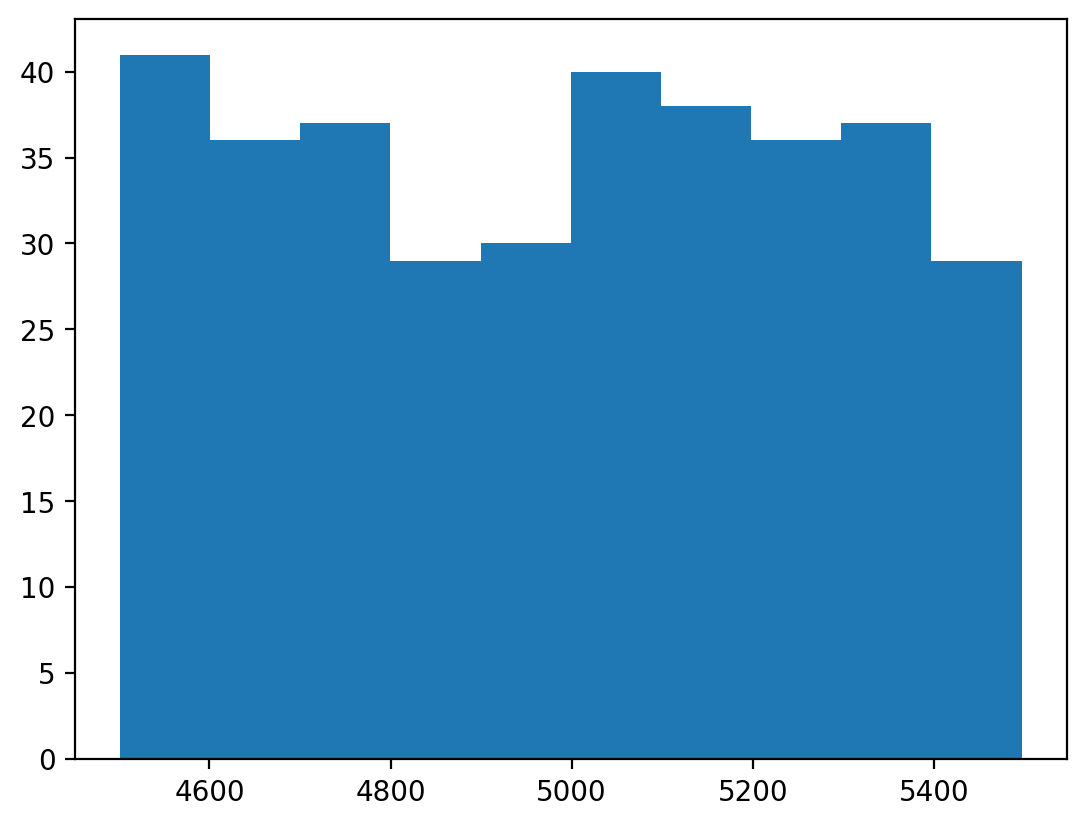

In [24]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [25]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [26]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## Anvend modellen på bavian-data

Jeg indlæser de gemte derived-count-filer fra notebook 03 og fitter to-island modellen på yellow baboon data. Modellen antager at alle samples er trukket fra en population og at den anden population kun bidrager via migration.

In [27]:
def load_baboon_ktons(path, n_samples_use, seed=0):
    p = Path(path)
    if not p.exists():
        print(f"[advarsel] {p} findes ikke — kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    df = df[df["nr_samples"] >= n_samples_use].copy()
    if len(df) == 0:
        print(f"[advarsel] {p} har ingen varianter med nr_samples >= {n_samples_use}")
        return None
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_samples_use,
    )
    k = k[(k > 0) & (k < n_samples_use)]
    return k

k_east = load_baboon_ktons(OUT_DIR / "derived_counts_P_cynocephalus.csv", nr_samples)

if k_east is not None:
    print(f"Antal segregerende SNPs efter subsampling (n={nr_samples}): {len(k_east):,}")

    feature_cols = [c for c in tbl.columns if c.startswith("descendants")]
    allowed = set(tuple(int(x) for x in r) for r in tbl[feature_cols].values)
    obs_baboon = []
    for k in k_east:
        o = [0] * len(feature_cols)
        if 0 < k - 1 < len(o):
            o[k - 1] = 1
        if tuple(o) in allowed:
            obs_baboon.append(o)
    print(f"Heraf brugbare under model: {len(obs_baboon):,}")

Antal segregerende SNPs efter subsampling (n=5): 450,201
Heraf brugbare under model: 394,124


In [28]:
if k_east is not None and len(obs_baboon) > 1000:
    rng = np.random.default_rng(1)
    if len(obs_baboon) > 5000:
        idx = rng.choice(len(obs_baboon), 5000, replace=False)
        obs_baboon_use = [obs_baboon[i] for i in idx]
    else:
        obs_baboon_use = obs_baboon

    svgd_baboon = joint_graph.svgd(
        observed_data=obs_baboon_use,
        fixed=[(3, mutation_rate)],
        n_iterations=150,
        n_particles=80,
        prior=[
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.0, 3.0]),
            None,
        ],
        learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
    )


In [14]:
svgd_baboon.summary(ci_method="hpd", ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         8.2436     6.3469     1.5677     4.1884       8.2958      
1          No         3.1806     2.8205     1.2779     0.6109       5.0645      
2          No         1.7144     1.1134     0.8068     0.0000       1.7486      
3          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


## Parameterkonvertering til biologiske enheder

In [29]:
# Konverter posterior-estimater til biologiske enheder
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
pi_P_cynocephalus = pi_df.loc["Yellow Baboon", "pi"]
Ne_ref = pi_P_cynocephalus / (4 * MUT_RATE)

print(f"pi (Yellow baboon):    {pi_P_cynocephalus:.6f}")
print(f"N_ref = pi/(4*mu):      {Ne_ref:,.0f} individer")
print()

res = svgd_baboon.get_results()
theta = res['theta_mean']

N1 = (1 / theta[0]) * Ne_ref
N2 = (1 / theta[1]) * Ne_ref
m_gen = theta[2] / (2 * Ne_ref)

results_table = pd.DataFrame({
    'Parameter': ['N1 (Yellow baboon)', 'N2 (Kinda)', 'Migration (m)'],
    'Coalescent-enheder': [f'{theta[0]:.4f}', f'{theta[1]:.4f}', f'{theta[2]:.4f}'],
    'Biologiske enheder': [f'{N1:,.0f} individer', f'{N2:,.0f} individer', f'{m_gen:.2e} /generation'],
})
print(results_table.to_string(index=False))

pi (Yellow baboon):    0.002922
N_ref = pi/(4*mu):      81,161 individer

         Parameter Coalescent-enheder   Biologiske enheder
N1 (Yellow baboon)             6.3209     12,840 individer
        N2 (Kinda)             2.6369     30,779 individer
     Migration (m)             0.8973 5.53e-06 /generation


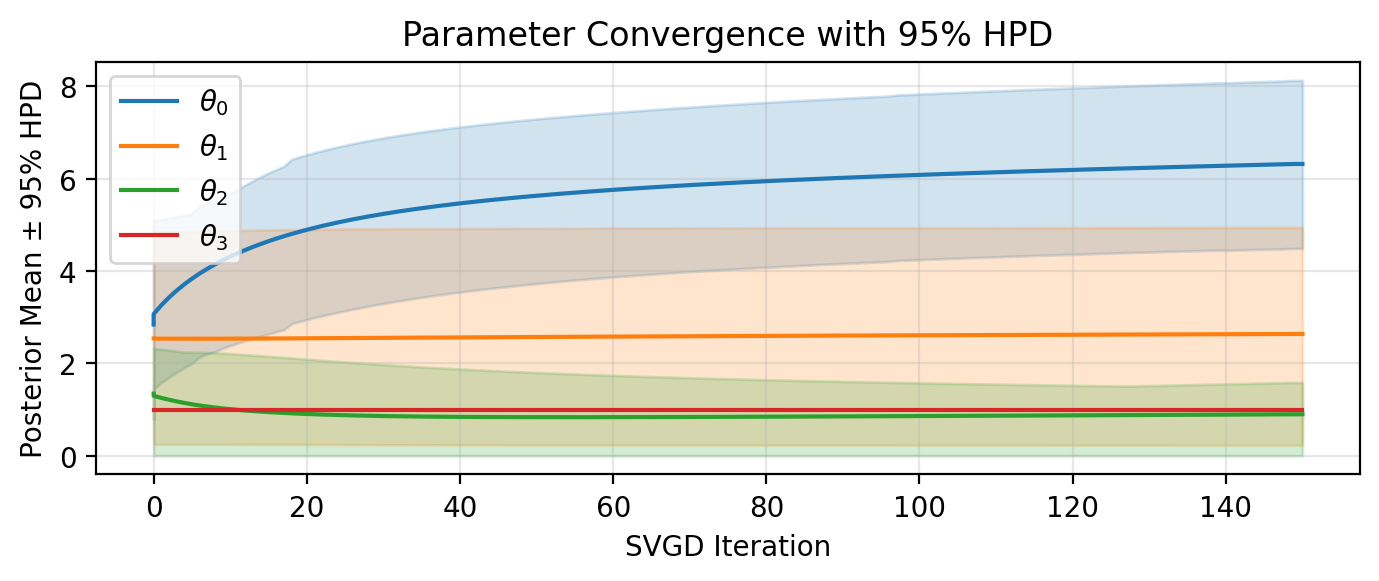

<Figure size 640x480 with 0 Axes>

In [30]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_ci(ci_method="hpd")
    plt.suptitle("Posterior CI — Yellow baboon")
    plt.show()

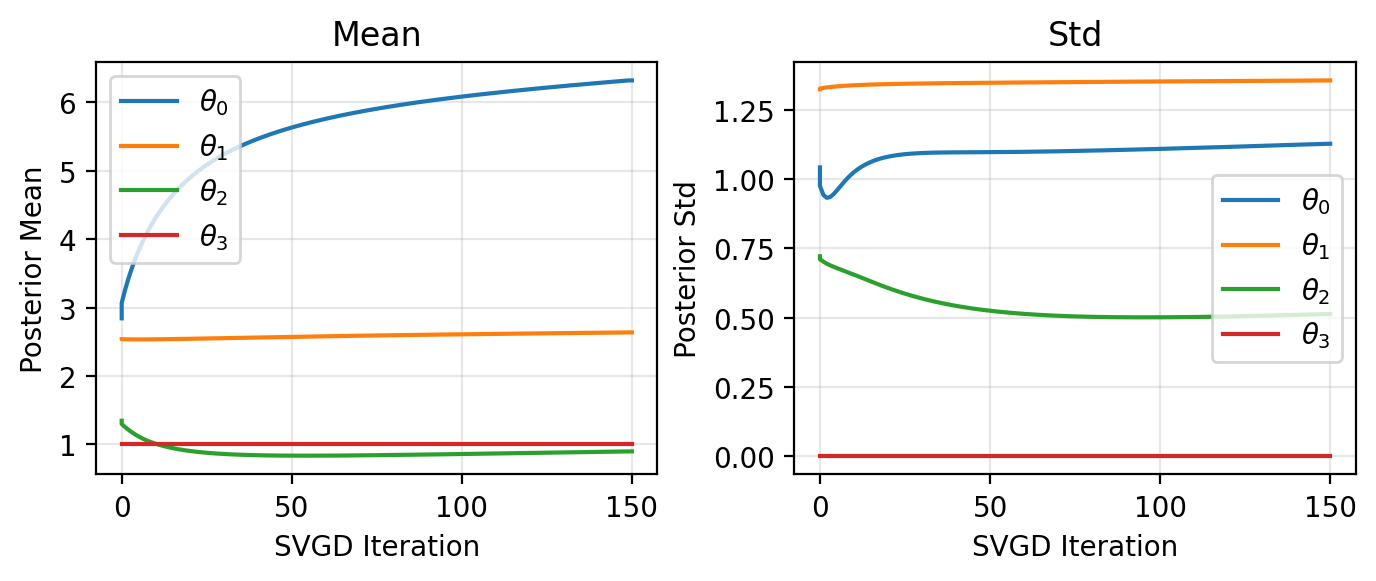

In [31]:
svgd_baboon.plot_convergence();

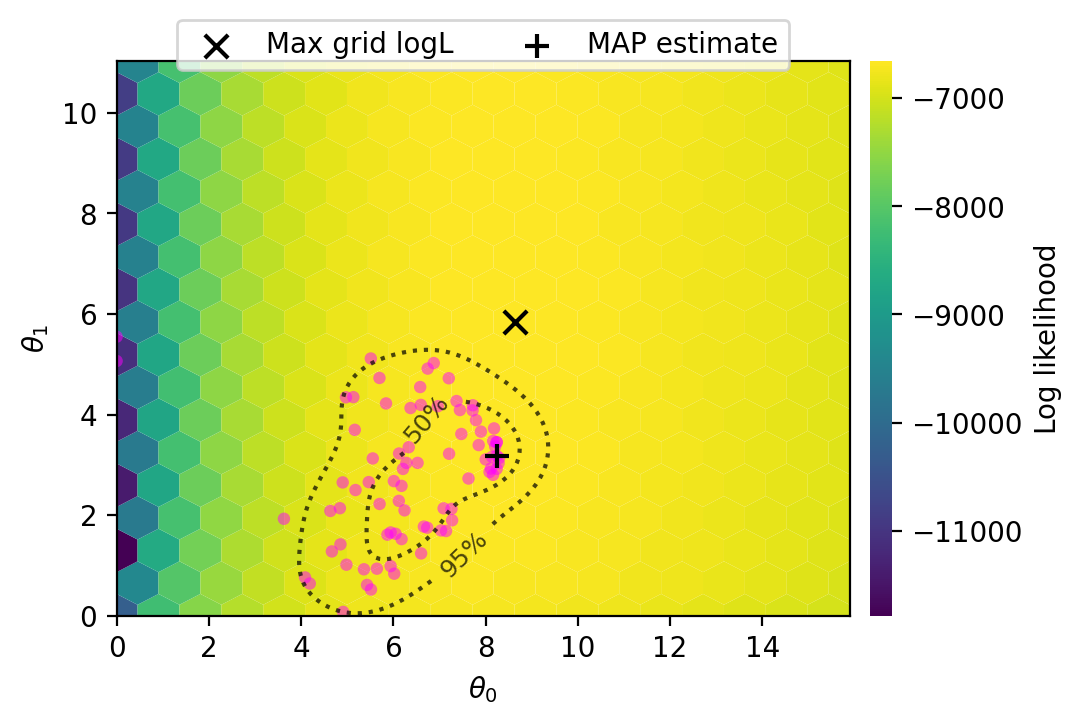

<Figure size 640x480 with 0 Axes>

In [22]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_hdr()
    plt.suptitle("Posterior HDR — Yellow baboon (Two-island)")
    plt.show()

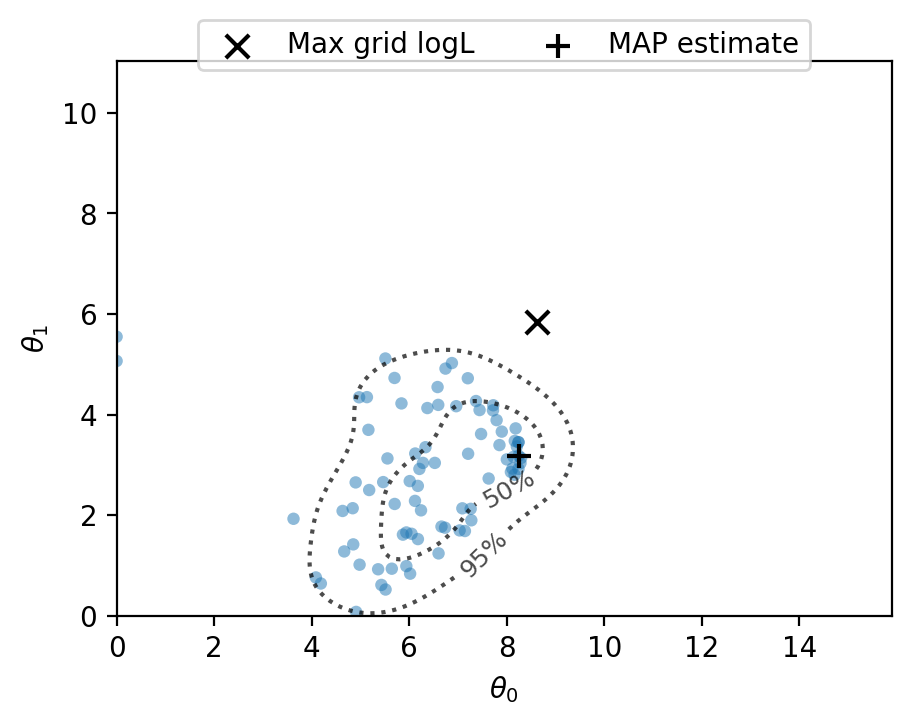

<Figure size 640x480 with 0 Axes>

In [23]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_hdr(hexgrid=False)
    plt.suptitle("Posterior HDR (scatter) — Yellow baboon (Two-island)")
    plt.show()

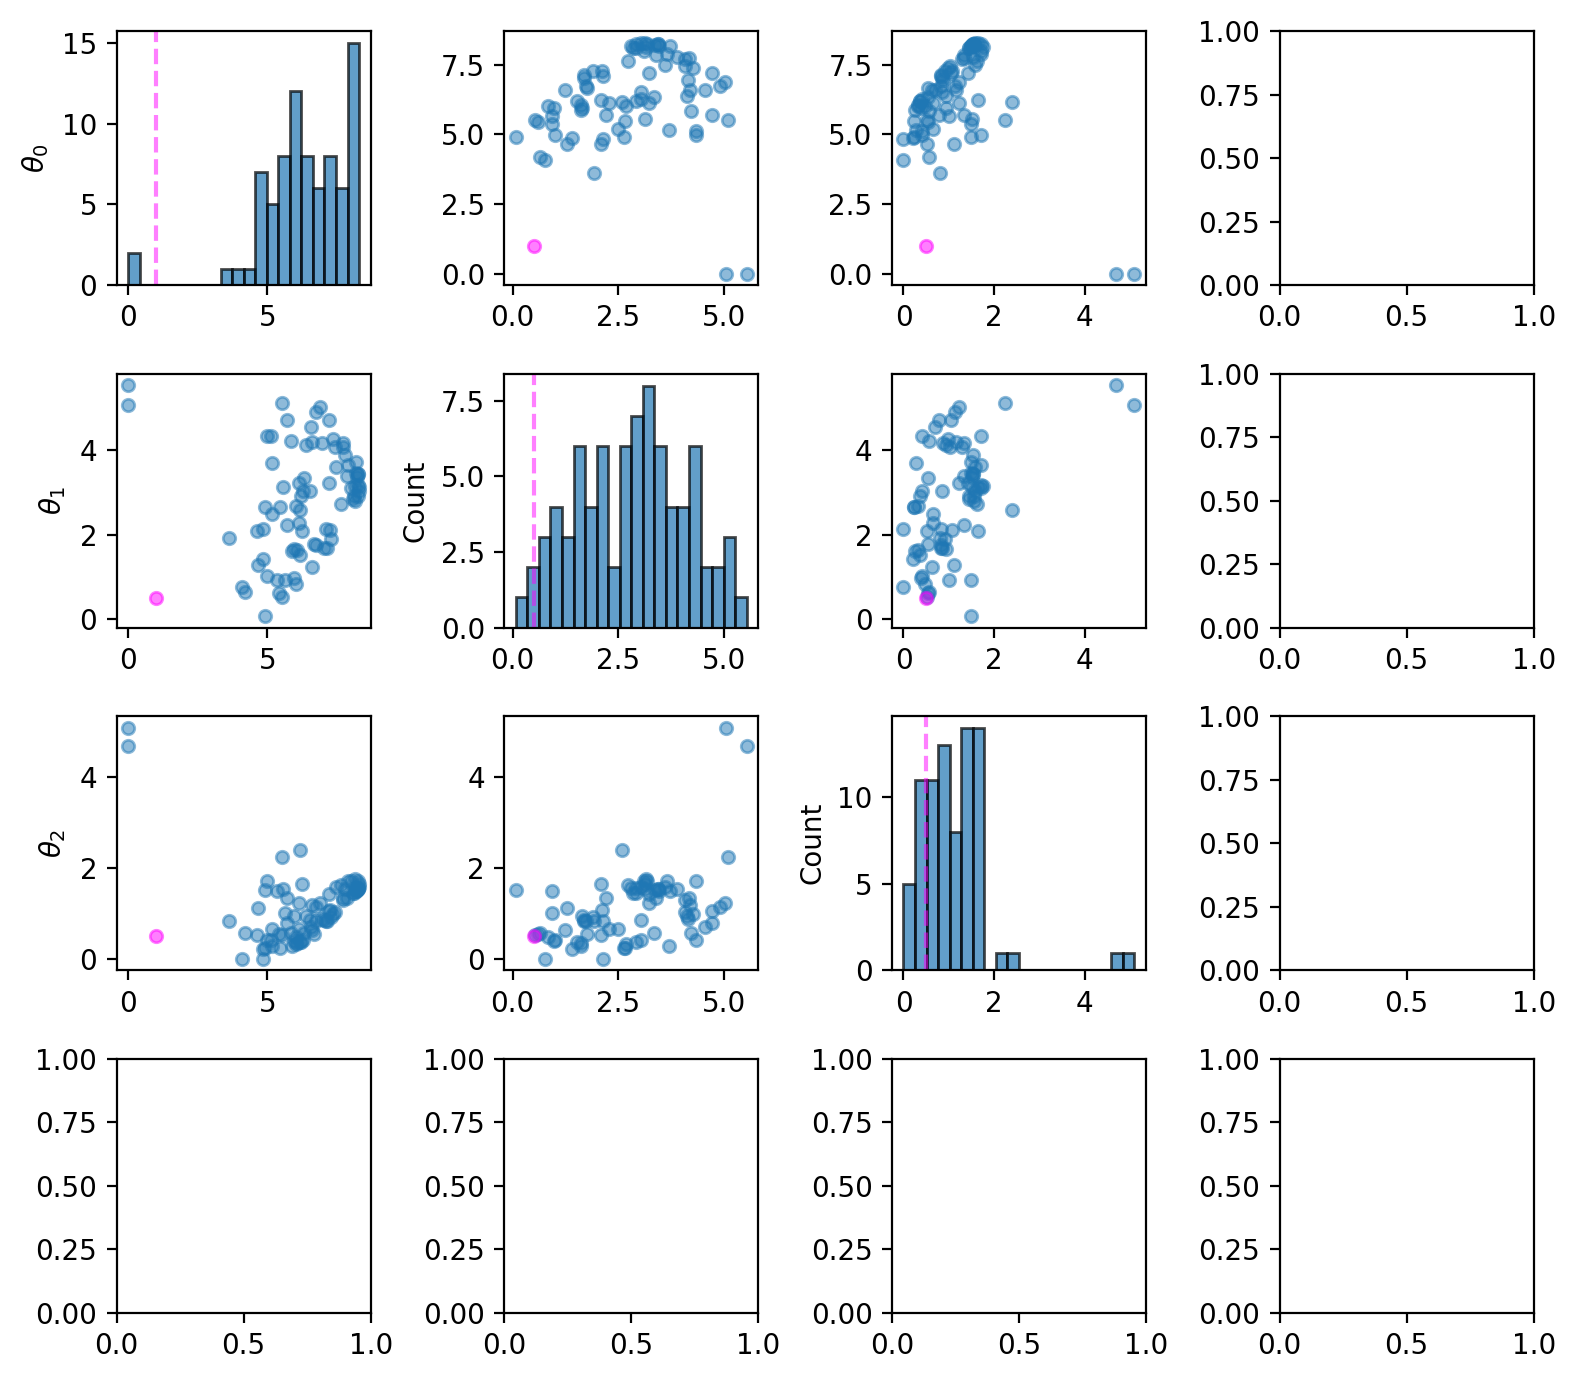

<Figure size 640x480 with 0 Axes>

In [24]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_pairwise(true_theta=true_theta)
    plt.suptitle("Posterior pairwise — Yellow baboon", y=1.02)
    plt.show()

## Samlet resultater — Yellow baboon (to-island model)

Her opsummerer jeg inferens-resultatet fra to-island modellen på Yellow baboon data.

**Estimaterne beskriver:**

- **N1** (Yellow baboon): Effektiv populationsstørrelse for den observerede population
- **N2** (implicit population): Den "anden ø" — svarer til den population der bidrager via migration; kan repræsentere en mix af alle de andre populationer
- **Migration rate**: Estimeret gennemsnitlig migrationshyppighed per generation

To-island modellen antager konstant migration bagud i tid og ingen ancestral split dvs. de to populationer eksisterede altid adskilt med migration. Det er en forenklet model. Sammenlignet med Sørensen et al. (2023) giver det et første estimat på migration

I notebook 05 (IM-modellen) tilføjer jeg en ancestral population og estimerer split-tidspunktet eksplicit.

In [32]:
pi_file = OUT_DIR / "pi_per_population.csv"
if pi_file.exists():
    pi_df = pd.read_csv(pi_file, index_col=0)
    if "Yellow Baboon" in pi_df.index:
        pi_east = pi_df.loc["Yellow Baboon", "pi"]
        Ne_ref = pi_east / (4 * MUT_RATE)
        print(f"pi (Yellow Baboon):  {pi_east:.6f}")
        print(f"Implied Ne_ref:       {Ne_ref:,.0f}")
        if "svgd_baboon" in dir():
            res = svgd_baboon.get_results()
            theta_mean = res["theta_mean"]
            N1_est = (1 / theta_mean[0]) * Ne_ref
            N2_est = (1 / theta_mean[1]) * Ne_ref
            m_est_gen = theta_mean[2] / (2 * Ne_ref)
            print("\nEstimater (posterior mean):")
            print(f"  N1 (Yellow Baboon):  {N1_est:,.0f}")
            print(f"  N2 (Kinda-lignende):  {N2_est:,.0f}")
            print(f"  Migration rate:       {m_est_gen:.2e} / generation")

pi (Yellow Baboon):  0.002922
Implied Ne_ref:       81,161

Estimater (posterior mean):
  N1 (Yellow Baboon):  12,840
  N2 (Kinda-lignende):  30,779
  Migration rate:       5.53e-06 / generation
